# Module 1: PyTorch Fundamentals

> **Series:** PyTorch Deep Dive → BERT Fine-Tuning for Embedding-Based Retrieval  
> **Prerequisites:** Basic Python, NumPy familiarity, linear algebra basics

---

## What you'll learn

| # | Section | Core concept |
|---|---------|-------------|
| 1 | Environment setup | Versions, GPU check |
| 2 | Tensors & operations | The core data structure |
| 3 | Device management | CPU ↔ GPU patterns |
| 4 | Autograd | Dynamic computation graphs |
| 5 | `torch.nn` | Module, layers, state_dict |
| 6 | Training loop | The canonical 5-step cycle |

By the end you'll have written a complete, working neural network **from scratch** — no high-level wrappers.


## 1 · Environment Setup & Imports


### PyTorch compute devices

PyTorch can run computations on three types of hardware. The device you pick determines **speed**, **memory capacity**, and **availability**:

| Device | Hardware | `torch.device` string | When to use |
|--------|----------|-----------------------|-------------|
| **CPU** | All x86 / ARM processors | `"cpu"` | Always available; fine for small models and data exploration |
| **CUDA** | NVIDIA GPUs (Tesla, RTX, A100, …) | `"cuda"` or `"cuda:0"` | Large model training; 10–100× faster than CPU for matrix ops |
| **MPS** | Apple Silicon GPUs (M1/M2/M3/M4) | `"mps"` | GPU acceleration on macOS — unified memory shared with CPU |

#### How unified memory (MPS) differs from CUDA

On a discrete NVIDIA GPU, the GPU has its own dedicated VRAM — data must be explicitly **copied** from CPU RAM to GPU VRAM via a PCIe bus, which is a bottleneck. On Apple Silicon, the CPU and GPU share the **same physical memory pool** (unified memory), so there is no copy cost; the GPU simply accesses the same memory pages the CPU uses.

```
CUDA (NVIDIA):   CPU RAM  ──PCIe──►  GPU VRAM   (separate pools)
MPS  (Apple):    CPU + GPU both read/write the same RAM   (unified)
```

#### Important constraints

- **`.numpy()` only works on CPU tensors.** Before calling `.numpy()` or passing to matplotlib, always call `.cpu()` first.
- MPS does not support every PyTorch operation yet — if you hit a `NotImplementedError`, add a fallback to CPU for that operation.
- When using CUDA, each GPU has a fixed VRAM budget; exceeding it raises an **Out of Memory (OOM)** error.


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"MPS     : {torch.backends.mps.is_available()}")

# Pick the best available device: CUDA → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device  : {device}")


PyTorch : 2.11.0
NumPy   : 2.4.4
CUDA    : False
MPS     : True
Device  : mps


---
## 2 · Tensors and Operations

### What is a tensor?

A **tensor** is the generalisation of scalars, vectors, and matrices to arbitrary rank:

| Rank | Name | Example shape |
|------|------|--------------|
| 0 | Scalar | `()` |
| 1 | Vector | `(n,)` |
| 2 | Matrix | `(m, n)` |
| 3+ | Tensor | `(batch, seq, features)` |

PyTorch tensors look like NumPy arrays but with two superpowers:
1. Can live on a **GPU**
2. Can track gradients for **automatic differentiation**

### Creating tensors


In [7]:
# Creation
scalar  = torch.tensor(3.14)
vector  = torch.tensor([1.0, 2.0, 3.0])
zeros   = torch.zeros(3, 4)
random  = torch.randn(2, 3)          # N(0,1)
arange  = torch.arange(0, 10, 2)     # like np.arange

for name, t in [("scalar", scalar), ("vector", vector), ("zeros", zeros), ("random", random)]:
    print(f"{name:8s}  shape={str(t.shape):15s}  dtype={t.dtype}")

# Reshape / view (no copy — shared memory)
flat = torch.arange(24, dtype=torch.float32)
mat  = flat.view(4, 6)
print(f"\nflat → mat: {flat.shape} → {mat.shape}")

print(f"flat: {flat}")
print(f"mat:\n{mat}")

# Indexing & slicing  (exactly like NumPy)
print(f"mat[0]     : {mat[0]}")
print(f"mat[:, 2]  : {mat[:, 2]}")
print(f"mat[1:3, 2:5]:\n{mat[1:3, 2:5]}")


scalar    shape=torch.Size([])   dtype=torch.float32
vector    shape=torch.Size([3])  dtype=torch.float32
zeros     shape=torch.Size([3, 4])  dtype=torch.float32
random    shape=torch.Size([2, 3])  dtype=torch.float32

flat → mat: torch.Size([24]) → torch.Size([4, 6])
flat: tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
mat:
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.]])
mat[0]     : tensor([0., 1., 2., 3., 4., 5.])
mat[:, 2]  : tensor([ 2.,  8., 14., 20.])
mat[1:3, 2:5]:
tensor([[ 8.,  9., 10.],
        [14., 15., 16.]])


### Broadcasting

PyTorch broadcasts dimensions from the **right**, stretching any size-1 dimension to match its partner:

```
(3, 1) + (1, 4)  →  (3, 4)   ✓
(3, 2) + (4, 2)  →  ERROR    ✗
```



In [8]:
# Broadcasting
a = torch.tensor([[1.0], [2.0], [3.0]])            # (3, 1)
b = torch.tensor([[10.0, 20.0, 30.0, 40.0]])       # (1, 4)
c = a + b                                           # (3, 4)
print(f"(3,1) + (1,4) → {c.shape}\n{c}\n")

(3,1) + (1,4) → torch.Size([3, 4])
tensor([[11., 21., 31., 41.],
        [12., 22., 32., 42.],
        [13., 23., 33., 43.]])




### NumPy bridge

`torch.from_numpy` and `.numpy()` create **zero-copy views** — modifying one modifies the other.

In [9]:
# NumPy bridge — shared memory
np_arr   = np.array([1.0, 2.0, 3.0])
torch_t  = torch.from_numpy(np_arr)
np_arr[0] = 99.0                        # mutate NumPy side
print(f"NumPy  : {np_arr}")
print(f"Torch  : {torch_t}   ← same memory, changed too!")

# Going the other way (CPU tensors only)
t = torch.randn(3)
arr = t.numpy()
print(f"\ntorch.randn(3).numpy() : {arr}")


NumPy  : [99.  2.  3.]
Torch  : tensor([99.,  2.,  3.], dtype=torch.float64)   ← same memory, changed too!

torch.randn(3).numpy() : [ 1.3231118  -0.62734073 -0.32926834]


---
## 3 · Device Management (CPU vs CUDA)

> **The golden rule:** every tensor in a computation must be on the **same device**.

Define a single `device` variable once at the top and pass it everywhere — your code then runs unchanged on CPU laptops and multi-GPU servers.


In [10]:
# Device-agnostic pattern: CUDA → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Two ways to put a tensor on device
x = torch.randn(3, 3).to(device)               # move existing tensor
y = torch.zeros(3, 3, device=device)           # create directly on device

print(f"x.device : {x.device}")
print(f"y.device : {y.device}")

# Move back to CPU for NumPy / matplotlib (MPS and CUDA tensors can't .numpy() directly)
x_cpu = x.cpu()
print(f"x_cpu.device : {x_cpu.device}")

if torch.cuda.is_available():
    print(f"\nGPU (CUDA) : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM       : {props.total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    print("\nGPU (MPS / Apple Silicon) — unified memory, no separate VRAM to report.")
else:
    print("\nNo GPU detected — running on CPU.")


x.device : mps:0
y.device : mps:0
x_cpu.device : cpu

GPU (MPS / Apple Silicon) — unified memory, no separate VRAM to report.


### `.cpu()` creates an independent copy

`x.cpu()` always allocates a **new tensor in CPU RAM** and copies the data across. The original tensor `x` is completely unaffected and stays on its device.

```
GPU/MPS memory:   x  ──copy──►  x_cpu  :CPU memory
```

This is different from `.view()` or `torch.from_numpy()`, which share memory within the same device.  
Cross-device tensors **cannot** share memory — GPU VRAM and CPU RAM are physically separate.

| Operation | Same memory? | Mutation propagates? |
|-----------|:------------:|:--------------------:|
| `.view()` / `.reshape()` | ✅ (usually) | ✅ |
| `torch.from_numpy()` | ✅ | ✅ |
| `.cpu()` / `.to(device)` | ❌ always a copy | ❌ |
| `.clone()` | ❌ always a copy | ❌ |


In [11]:
# Start with a tensor on whichever device is available
x = torch.tensor([1.0, 2.0, 3.0], device=device)
x_cpu = x.cpu()

print(f"x       device : {x.device}")       # e.g. mps:0 or cuda:0
print(f"x_cpu   device : {x_cpu.device}")   # cpu

# Mutate x_cpu — does x change?
x_cpu[0] = 999.0
print(f"\nAfter x_cpu[0] = 999:")
print(f"  x_cpu : {x_cpu}")   # [999, 2, 3]
print(f"  x     : {x}")       # [1, 2, 3]  ← unchanged, separate copy

# Mutate x (in-place) — does x_cpu change?
x[1] = 888.0
print(f"\nAfter x[1] = 888:")
print(f"  x     : {x}")       # [1, 888, 3]
print(f"  x_cpu : {x_cpu}")   # [999, 2, 3]  ← unchanged


x       device : mps:0
x_cpu   device : cpu

After x_cpu[0] = 999:
  x_cpu : tensor([999.,   2.,   3.])
  x     : tensor([1., 2., 3.], device='mps:0')

After x[1] = 888:
  x     : tensor([  1., 888.,   3.], device='mps:0')
  x_cpu : tensor([999.,   2.,   3.])


---
## 4 · Autograd and Backpropagation

### How PyTorch builds the computation graph

Every operation on a `requires_grad=True` tensor adds a node to a **dynamic DAG**. Calling `.backward()` traverses it in reverse, accumulating gradients via the **chain rule**:

$$\frac{d\mathcal{L}}{dx} = \frac{d\mathcal{L}}{dz} \cdot \frac{dz}{dy} \cdot \frac{dy}{dx}$$

### Worked example

Consider $y = (x + 2)^2 - 1$ at $x = 1.0$:

$$\frac{dy}{dx} = 2(x + 2) = 2 \times 3 = 6$$


In [12]:
# Leaf tensor — gradient tracking enabled
x = torch.tensor(1.0, requires_grad=True)

# Forward pass — graph is built silently
a = x + 2      # grad_fn: AddBackward
b = a ** 2     # grad_fn: PowBackward
y = b - 1      # grad_fn: SubBackward

print(f"y                 = {y.item():.1f}  (expected 8.0)")
print(f"y.grad_fn         = {y.grad_fn}")

# Backward pass — fills .grad on every leaf
y.backward()

print(f"\nAutograd dy/dx    = {x.grad.item():.1f}  (expected 6.0)")
print(f"Manual  2*(x+2)   = {2 * (x.item() + 2):.1f}")


y                 = 8.0  (expected 8.0)
y.grad_fn         = <SubBackward0 object at 0x1181b8550>

Autograd dy/dx    = 6.0  (expected 6.0)
Manual  2*(x+2)   = 6.0


### Visualising the computation graph

We use `torchviz` to render the DAG that PyTorch built during the forward pass.  
Each **box** is an operation (backward function); the **leaf** at the bottom is our input `x`.  
Arrows flow from outputs back to inputs — the direction gradients travel during `.backward()`.

```bash
pip install torchviz   # requires graphviz system package too: brew install graphviz
```


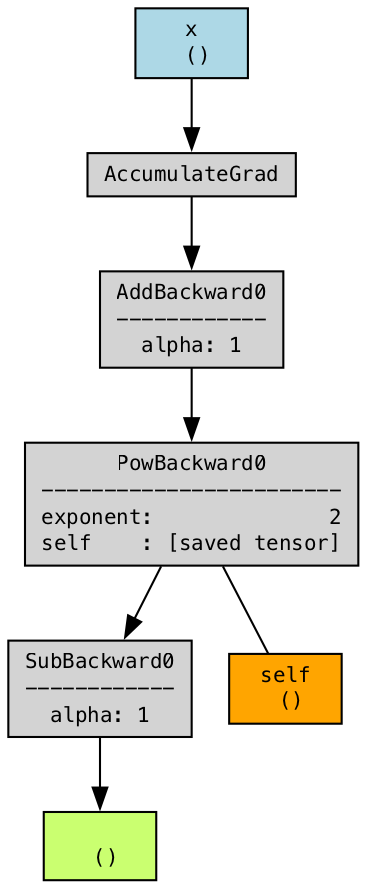

In [19]:
from torchviz import make_dot
from IPython.display import Image, display

# Rebuild the graph cleanly (separate from the autograd cell above)
x_vis = torch.tensor(1.0, requires_grad=True)
a_vis = x_vis + 2
b_vis = a_vis ** 2
y_vis = b_vis - 1

dot = make_dot(
    y_vis,
    params={"x": x_vis},
    show_attrs=True,
    show_saved=True,
)
dot.attr(rankdir="TB", size="4,6", dpi="150")

# Render and display inline — no file saved to disk
display(Image(dot.pipe(format="png")))


#### Reading the graph

| Element | Meaning |
|---------|---------|
| **Blue box** (`x`) | Leaf tensor — the variable we differentiate with respect to |
| **Gray boxes** | Backward functions — one per forward operation |
| **Orange box** (`self`) | A tensor *saved* during the forward pass and needed by the backward pass |
| **Green box** | The output tensor `y` (the root of the graph) |
| **Arrows** | Forward computation order — from inputs toward output. Gradients flow in the *reverse* direction during `.backward()` |

**What is `alpha`?**  
PyTorch's internal `add` and `sub` kernels have the signature  
`torch.add(input, other, alpha=α)` which computes `input + α × other`.  
When you write `x + 2` or `b - 1`, `alpha` defaults to `1` (no extra scaling), so torchviz shows `alpha: 1`.  
During backprop, `AddBackward0` multiplies the incoming gradient by `alpha` before passing it on — with `alpha=1` the gradient is unchanged.  
If you wrote something like `torch.add(x, other, alpha=5)`, you would see `alpha: 5` and the gradient would be scaled by 5.

**What is the saved `self` tensor (orange)?**  
`PowBackward0` (computing $a^2$) needs the *base* $a$ at backward time to evaluate the power-rule derivative $2a$.  
PyTorch saves it automatically during the forward pass and torchviz colours it orange to distinguish saved intermediate values from the operation nodes.


### `torch.no_grad()` — disabling the graph

Building the graph costs memory and time. During **inference** and **validation** you never need gradients — always wrap those sections:

```python
with torch.no_grad():
    predictions = model(x)      # no graph built, ~30% faster
```

> ⚠️ Forgetting `no_grad` in a val loop is one of the most common causes of **GPU OOM** errors.


In [13]:
x = torch.tensor(2.0, requires_grad=True)

with torch.no_grad():
    y_no_grad = x * 3
    print(f"Inside  no_grad — requires_grad : {y_no_grad.requires_grad}")  # False

y_grad = x * 3
print(f"Outside no_grad — requires_grad : {y_grad.requires_grad}")         # True

# .detach() — get a tensor's values without its gradient history
z = y_grad.detach()
print(f"After   detach  — requires_grad : {z.requires_grad}")              # False


Inside  no_grad — requires_grad : False
Outside no_grad — requires_grad : True
After   detach  — requires_grad : False


In [16]:
import time

# Large matrix multiply — enough work to make the difference measurable
A = torch.randn(1024, 1024, device=device, requires_grad=True)
B = torch.randn(1024, 1024, device=device)
REPS = 200

# --- With gradient tracking ---
if device.type == "mps":
    torch.mps.synchronize()
elif device.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
for _ in range(REPS):
    C = (A @ B).sum()
if device.type == "mps":
    torch.mps.synchronize()
elif device.type == "cuda":
    torch.cuda.synchronize()
t_grad = (time.perf_counter() - t0) * 1000  # ms

# --- Without gradient tracking ---
if device.type == "mps":
    torch.mps.synchronize()
elif device.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(REPS):
        C = (A @ B).sum()
if device.type == "mps":
    torch.mps.synchronize()
elif device.type == "cuda":
    torch.cuda.synchronize()
t_no_grad = (time.perf_counter() - t0) * 1000  # ms

print(f"With    grad  : {t_grad:.1f} ms  ({REPS} reps)")
print(f"With no_grad  : {t_no_grad:.1f} ms  ({REPS} reps)")
print(f"Speedup       : {t_grad / t_no_grad:.2f}×")


With    grad  : 45.2 ms  (200 reps)
With no_grad  : 37.2 ms  (200 reps)
Speedup       : 1.22×


---
## 5 · Building Neural Networks with `torch.nn`

### The `nn.Module` contract

Every PyTorch model subclasses `nn.Module`. You implement exactly two methods:

| Method | Responsibility |
|--------|---------------|
| `__init__` | Register sub-modules & parameters as attributes |
| `forward(x)` | Define the computation (call via `model(x)`) |

PyTorch auto-discovers all registered parameters for optimization, serialization, and device movement.

### Common layers

| Layer | What it does | Key hyperparameters |
|-------|-------------|-------------------|
| `nn.Linear(in, out)` | $y = xW^T + b$ | `in_features`, `out_features` |
| `nn.Dropout(p)` | At each forward pass during training, independently sets each activation to **0** with probability `p` and scales the surviving ones up by $\frac{1}{1-p}$ to keep the expected sum unchanged. This prevents neurons from co-adapting and acts as regularisation. At eval time it is a no-op. | `p` — drop probability (typically 0.1–0.5) |
| `nn.LayerNorm(d)` | Normalise across features (used in Transformers) | `normalized_shape` |
| `nn.ReLU()` | $\max(0, x)$ | — |


In [17]:
class MLP(nn.Module):
    """3-layer MLP with dropout and layer normalisation."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1  = nn.Linear(input_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.act  = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)    # (B, in)  → (B, hidden)
        x = self.norm(x)   # normalise feature dim
        x = self.act(x)    # non-linearity
        x = self.drop(x)   # regularise (no-op at eval time)
        return self.fc2(x) # (B, hidden) → (B, out)

model = MLP(input_dim=16, hidden_dim=64, output_dim=4).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")


MLP(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (act): ReLU()
  (drop): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 1,476


#### MLP — full mathematical formulation

Given an input $\mathbf{x} \in \mathbb{R}^{d_{\text{in}}}$, the model computes:

$$\mathbf{h}_1 = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1, \qquad \mathbf{W}_1 \in \mathbb{R}^{d_h \times d_{\text{in}}}, \quad \mathbf{b}_1 \in \mathbb{R}^{d_h}$$

$$\hat{\mathbf{h}}_1 = \text{LayerNorm}(\mathbf{h}_1) = \frac{\mathbf{h}_1 - \mu}{\sigma + \epsilon} \odot \boldsymbol{\gamma} + \boldsymbol{\beta}$$

where $\mu = \frac{1}{d_h}\sum_{j=1}^{d_h} h_{1,j}$ and $\sigma = \sqrt{\frac{1}{d_h}\sum_{j=1}^{d_h}(h_{1,j}-\mu)^2}$ are computed **over all $d_h$ features of a single sample** (not across the batch). Every sample is normalised independently using its own mean and std. $\boldsymbol{\gamma}, \boldsymbol{\beta} \in \mathbb{R}^{d_h}$ are learned per-feature scale/shift parameters shared across all samples.

> **contrast with BatchNorm**, which computes $\mu$ and $\sigma$ *across the batch dimension* for each feature — making it batch-size-dependent and unsuitable for small batches or sequences of variable length. LayerNorm has neither of those limitations, which is why Transformers use it exclusively.

$$\mathbf{a} = \text{ReLU}(\hat{\mathbf{h}}_1) = \max(\mathbf{0},\, \hat{\mathbf{h}}_1)$$

$$\tilde{\mathbf{a}} = \text{Dropout}(\mathbf{a}) = \mathbf{a} \odot \mathbf{m} \cdot \frac{1}{1-p}, \qquad \mathbf{m}_i \sim \text{Bernoulli}(1-p) \text{ (train only)}$$

$$\mathbf{y} = \mathbf{W}_2\, \tilde{\mathbf{a}} + \mathbf{b}_2, \qquad \mathbf{W}_2 \in \mathbb{R}^{d_{\text{out}} \times d_h}, \quad \mathbf{b}_2 \in \mathbb{R}^{d_{\text{out}}}$$

For this notebook: $d_{\text{in}} = 16$, $d_h = 64$, $d_{\text{out}} = 4$, $p = 0.1$.

**Parameter count:**

| Component | Parameters |
|-----------|-----------|
| $\mathbf{W}_1, \mathbf{b}_1$ | $64 \times 16 + 64 = 1{,}088$ |
| $\boldsymbol{\gamma}, \boldsymbol{\beta}$ (LayerNorm) | $64 + 64 = 128$ |
| $\mathbf{W}_2, \mathbf{b}_2$ | $4 \times 64 + 4 = 260$ |
| **Total** | **1,476** |


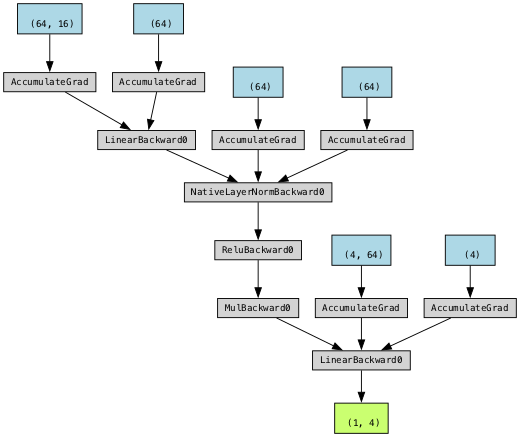

In [25]:
from torchviz import make_dot
from IPython.display import Image, display

# ── Option A: torchviz — forward-pass ops only (no parameter/saved-tensor clutter) ──
x_vis = torch.randn(1, 16, device=device)
model.train()
out_vis = model(x_vis)

dot = make_dot(out_vis)   # no params / show_attrs / show_saved → ops only
dot.attr(rankdir="TB", size="4,8", dpi="130")
display(Image(dot.pipe(format="png")))


In [26]:
from torchinfo import summary

# ── Option B: torchinfo — clean layer table (like Keras model.summary()) ──
summary(model, input_size=(1, 16), device=device, col_names=["input_size", "output_size", "num_params", "trainable"])


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MLP                                      [1, 16]                   [1, 4]                    --                        True
├─Linear: 1-1                            [1, 16]                   [1, 64]                   1,088                     True
├─LayerNorm: 1-2                         [1, 64]                   [1, 64]                   128                       True
├─ReLU: 1-3                              [1, 64]                   [1, 64]                   --                        --
├─Dropout: 1-4                           [1, 64]                   [1, 64]                   --                        --
├─Linear: 1-5                            [1, 64]                   [1, 4]                    260                       True
Total params: 1,476
Trainable params: 1,476
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
F

In [18]:
# Inspect all named parameters
print("Parameter shapes:")
for name, p in model.named_parameters():
    print(f"  {name:20s}  {list(p.shape)}")

# Test a forward pass
x_dummy = torch.randn(8, 16, device=device)  # batch of 8
out = model(x_dummy)
print(f"\nInput : {x_dummy.shape}  →  Output : {out.shape}")


Parameter shapes:
  fc1.weight            [64, 16]
  fc1.bias              [64]
  norm.weight           [64]
  norm.bias             [64]
  fc2.weight            [4, 64]
  fc2.bias              [4]

Input : torch.Size([8, 16])  →  Output : torch.Size([8, 4])


### Saving & Loading — `state_dict`

`state_dict()` returns an `OrderedDict` of parameter tensors. This is the **recommended** way to persist models — it decouples the weights from the code.

```python
torch.save(model.state_dict(), "checkpoint.pt")   # save
model.load_state_dict(torch.load("checkpoint.pt")) # restore
```


In [19]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    path = os.path.join(tmpdir, "mlp.pt")

    # Save
    torch.save(model.state_dict(), path)

    # Restore into a fresh model
    model2 = MLP(16, 64, 4).to(device)
    model2.load_state_dict(torch.load(path, map_location=device))
    model2.eval()

    # Verify outputs are identical
    model.eval()
    with torch.no_grad():
        out1 = model(x_dummy)
        out2 = model2(x_dummy)

    print(f"Outputs match: {torch.allclose(out1, out2)}")


Outputs match: True


---
## 6 · Training Loop Anatomy

### The 5-step cycle

Every training step follows the same pattern:

```
1. optimizer.zero_grad()        # clear stale gradients from last step
2. output = model(x)            # forward pass
3. loss   = criterion(output, y) # scalar loss
4. loss.backward()              # backprop → populate .grad
5. optimizer.step()             # gradient descent update
```

### Learning rate scheduler

After the optimizer step you also call `scheduler.step()` to adjust the learning rate according to a schedule (cosine, linear warmup, etc.).

### `model.train()` vs `model.eval()`

These switch **stateful layers** like `Dropout` and `BatchNorm`:
- `model.train()` → Dropout is active, BatchNorm uses batch statistics  
- `model.eval()`  → Dropout is off, BatchNorm uses running statistics

> Always call `model.eval()` before inference, and `model.train()` at the start of each training epoch.


In [20]:
# --- Synthetic regression: y = 2x₀ - 3x₁ + ε ---

class SyntheticDataset(Dataset):
    def __init__(self, n: int = 1000, seed: int = 42):
        torch.manual_seed(seed)
        self.X = torch.randn(n, 2)
        w = torch.tensor([2.0, -3.0])
        self.y = (self.X @ w + 0.1 * torch.randn(n)).unsqueeze(1)  # (n, 1)

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

dataset   = SyntheticDataset(1000)
train_ds, val_ds = torch.utils.data.random_split(dataset, [800, 200])
train_dl  = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl    = DataLoader(val_ds,   batch_size=64, shuffle=False)

print(f"Train batches : {len(train_dl)}")
print(f"Val   batches : {len(val_dl)}")
xb, yb = next(iter(train_dl))
print(f"Batch shapes  : X={xb.shape}  y={yb.shape}")


Train batches : 25
Val   batches : 4
Batch shapes  : X=torch.Size([32, 2])  y=torch.Size([32, 1])


In [21]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Simple linear regression model
reg_model = nn.Linear(2, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

train_losses, val_losses = [], []

for epoch in range(20):
    # ---- Train ----
    reg_model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()           # 1. clear gradients
        pred = reg_model(xb)            # 2. forward
        loss = criterion(pred, yb)      # 3. loss
        loss.backward()                 # 4. backprop
        optimizer.step()                # 5. update
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_dl))
    scheduler.step()

    # ---- Validate ----
    reg_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = reg_model(xb)
            val_loss += criterion(pred, yb).item()
    val_losses.append(val_loss / len(val_dl))

print(f"Final train MSE : {train_losses[-1]:.4f}")
print(f"Final val   MSE : {val_losses[-1]:.4f}")
print(f"Learned weights : {reg_model.weight.data}  (expect ~[2, -3])")


Final train MSE : 1.4300
Final val   MSE : 1.0666
Learned weights : tensor([[ 1.5781, -1.8959]], device='mps:0')  (expect ~[2, -3])


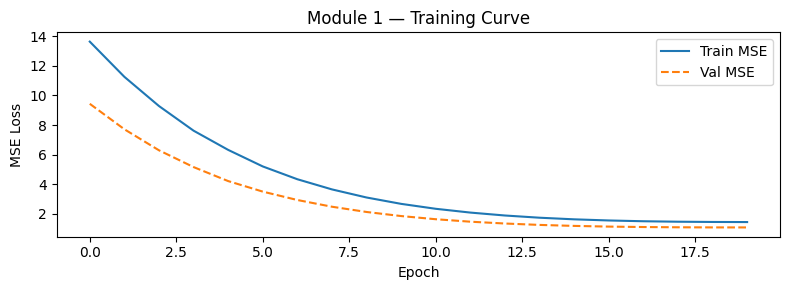

In [22]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses,   label="Val MSE",  linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Module 1 — Training Curve"); plt.legend(); plt.tight_layout()
plt.show()


---
## Summary

| Concept | Key takeaway |
|---------|-------------|
| Tensors | N-dimensional arrays with GPU support & gradient tracking |
| Broadcasting | Implicit shape expansion — know the rules to avoid bugs |
| Autograd | Dynamic graph; call `backward()` once per loss |
| `no_grad` | **Always** use in validation/inference loops |
| `nn.Module` | Subclass it, register layers in `__init__`, implement `forward` |
| Training loop | `zero_grad → forward → loss → backward → step` |
| `train/eval` | Flips Dropout & BatchNorm — don't forget `model.eval()` |

**Next:** [Module 2 — Embedding-Based Retrieval: Theory & Math](02_embeddings_theory.ipynb)
